In [79]:
import os
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"


from ultralytics import YOLO
import numpy as np
import cv2
from PIL import Image
from matplotlib import pyplot as plt

import sys  
sys.path.insert(1, '../src')

import coin_model

from multiprocessing import Pool

In [257]:
test_path = '/home/tripwireguy/PycharmProjects/Coin-Jo/Data/raw/Jordan-Coins-Detection-1/test/IMG_6761_jpg.rf.d6c2d062c9d1d72fa1478d863327a3de.jpg'

In [258]:
test_image = cv2.imread(test_path)
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)

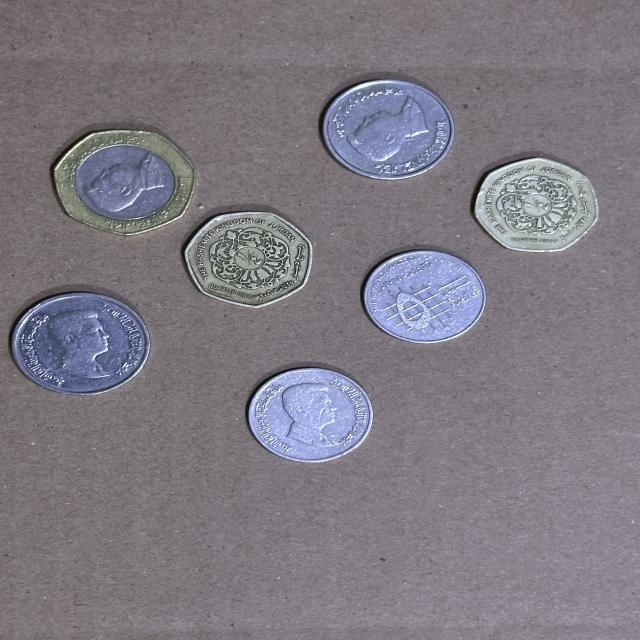

In [319]:
Image.fromarray(test_image)


In [320]:
img_gray = cv2.cvtColor(test_image, cv2.COLOR_RGB2GRAY)

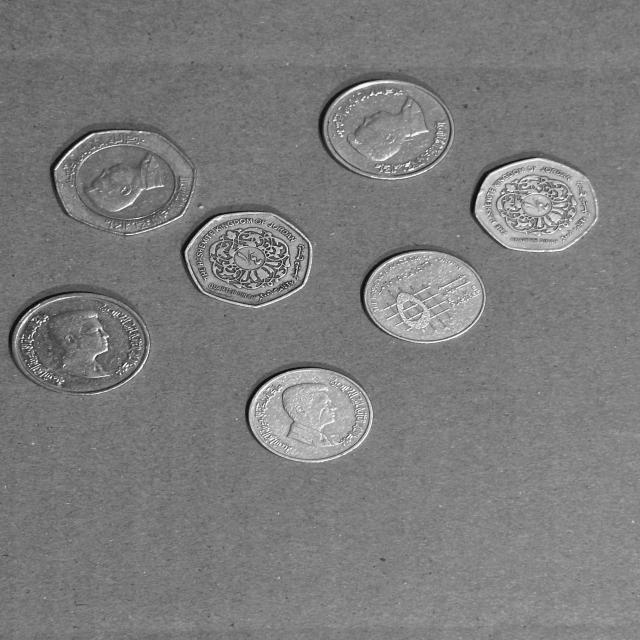

In [321]:
Image.fromarray(img_gray)

In [322]:
kernel_w = 3
img_preprocessed = cv2.GaussianBlur(img_gray, (kernel_w, kernel_w),0)

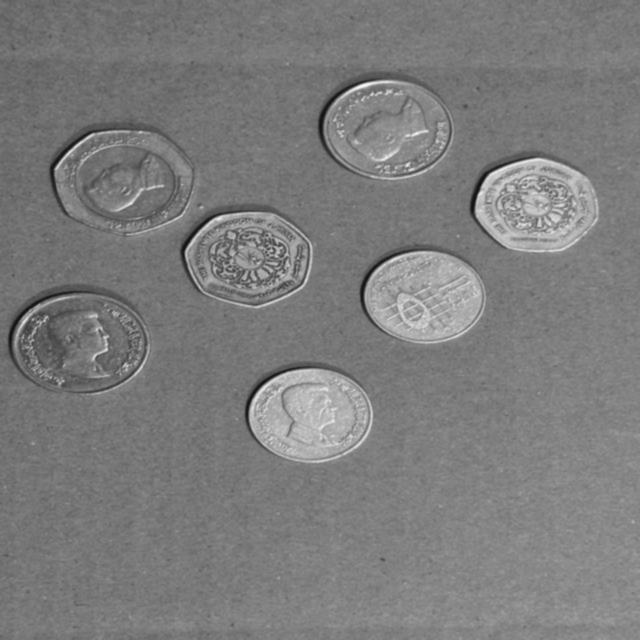

In [323]:
Image.fromarray(img_preprocessed)

In [364]:
edges = cv2.Canny(img_preprocessed,
                 50,150, apertureSize=3)

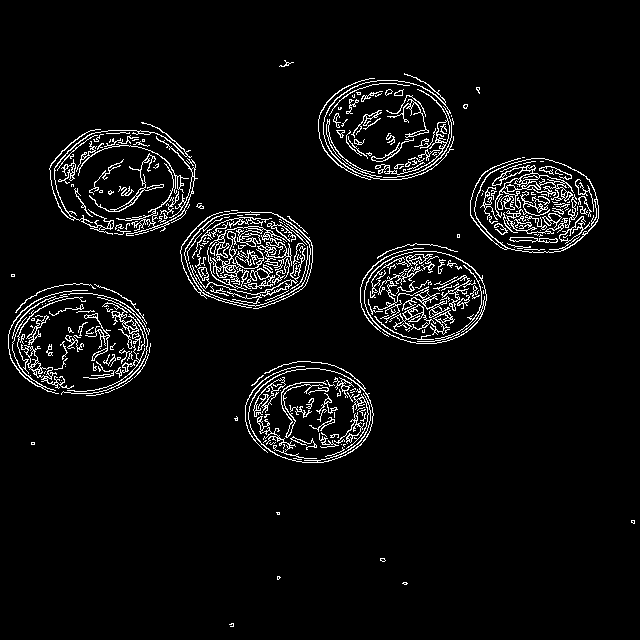

In [365]:
Image.fromarray(edges)

In [366]:
# img_dil = cv2.dilate(edges, None, iterations = 1)

In [367]:
# Image.fromarray(img_dil)

In [368]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations = 1)
# closed = cv2.morphologyEx(closed, cv2.MORPH_ERODE, kernel, iterations = 1)

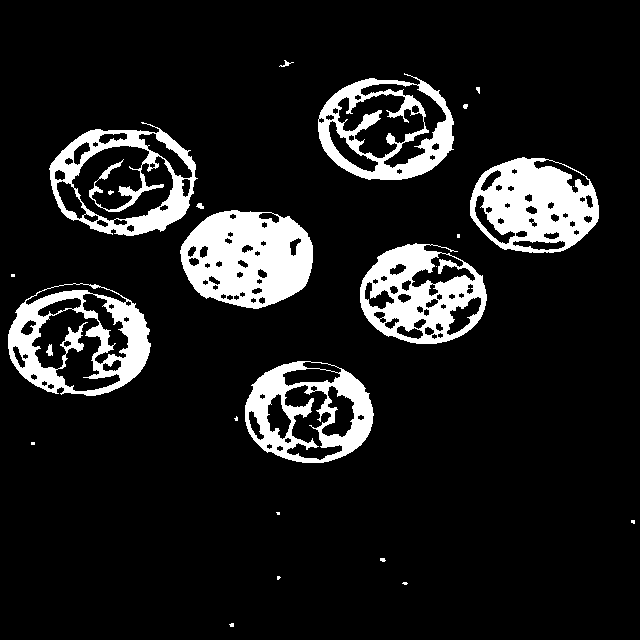

In [369]:
Image.fromarray(closed)

In [370]:
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [371]:
mask_ = np.zeros_like(edges)
cv2.drawContours(mask_, contours, -1, 255, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(640, 640), dtype=uint8)

In [372]:
useable_contours = []
for cnt in contours:
    
    area = cv2.contourArea(cnt)
    if area < 500:
        continue

    perimiter = cv2.arcLength(cnt, True)
    if perimiter == 0:
        continue
        
    circularity = (4 * np.pi * area) / perimiter ** 2
    print(circularity)
    if circularity > 0.25:
        useable_contours.append(cnt)

0.8354374708708094
0.7246363639818336
0.5650960374837587
0.8209827033615379
0.8418146033297957
0.5881072073622626
0.6689117441210023


In [373]:
mask = np.zeros_like(edges)
cv2.drawContours(mask, useable_contours, -1, 255, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(640, 640), dtype=uint8)

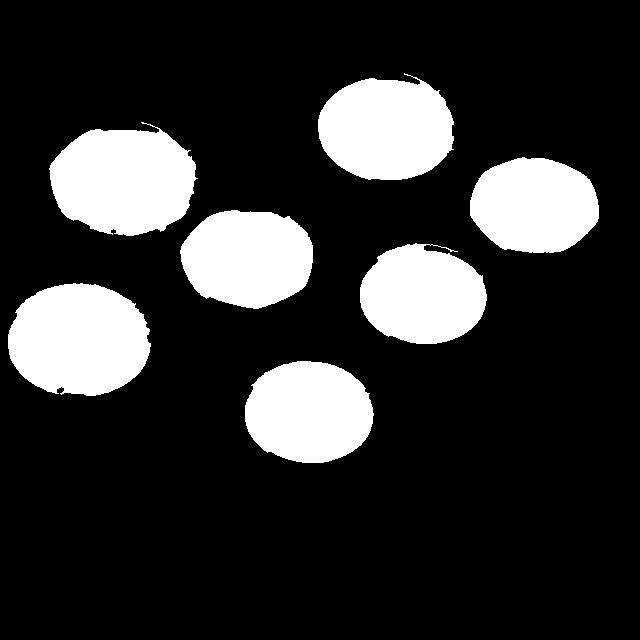

In [374]:
Image.fromarray(mask)

In [375]:
img_proc = cv2.bitwise_and(img_gray, mask)

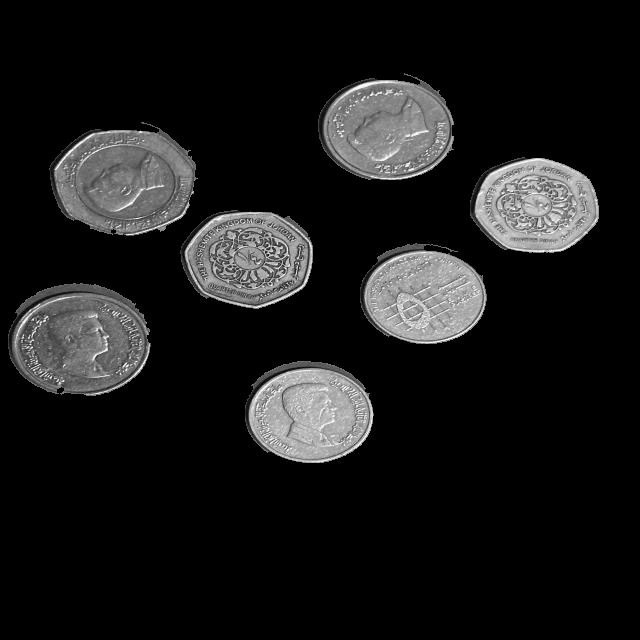

In [376]:
Image.fromarray(img_proc)

In [377]:
x_, y_, w_, h_ = cv2.boundingRect(useable_contours[0])

In [378]:
bbox_img = np.zeros_like(img_proc)

In [379]:
print(f'{w_ = }')
print(f'{h_ = }')

w_ = 129
h_ = 102


In [396]:
for cnt in useable_contours:

    x_, y_, w_, h_ = cv2.boundingRect(cnt)
    
    for x in range(x_, x_ + w_):
        for y in range(y_, y_ + h_):
            bbox_img[y ,x] = np.uint8(255)

In [397]:
bbox_img_grey = cv2.bitwise_and(bbox_img, img_proc)

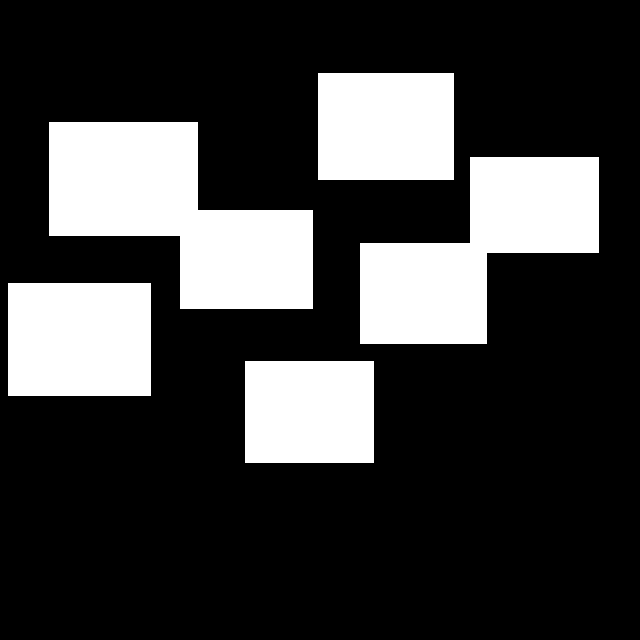

In [398]:
Image.fromarray(bbox_img)

In [391]:
bbox_crop_ = bbox_img_grey[y_: y_ + h_, x_: x_ + w_]

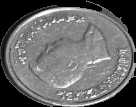

In [392]:
Image.fromarray(bbox_crop_)

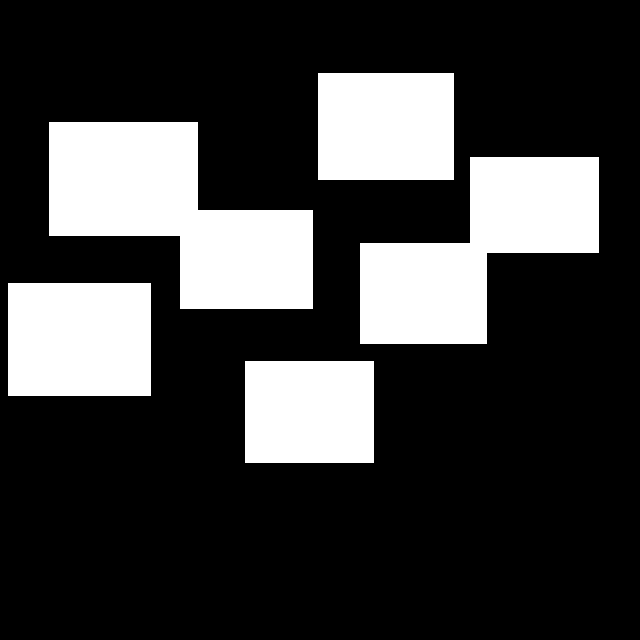

In [393]:
Image.fromarray(bbox_img)

In [394]:
bboxs = []
for cnt in useable_contours:
    x, y, w, h = cv2.boundingRect(cnt)
    
    bbox_crop = test_image[y: y + h, x: x + w]
    bboxs.append(bbox_crop)

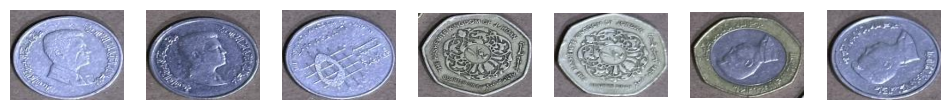

In [395]:
fig, ax = plt.subplots(nrows=1,ncols=len(bboxs),figsize=(12,6))


for i, img in enumerate(bboxs):
    ax[i].imshow(img)
    ax[i].axis('OFF')

plt.show()

In [348]:
model = coin_model.CoinModel()

In [349]:
img_model_test = bboxs[0]

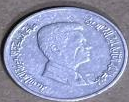

In [350]:
Image.fromarray(img_model_test)

In [351]:
img_model_test.shape

(102, 129, 3)

In [352]:
pred = model.predict_image(img_model_test)
pred.sort()
pred = pred[::-1]
print(f'{pred[0][1] = }')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
pred[0][1] = '5 Piasters'


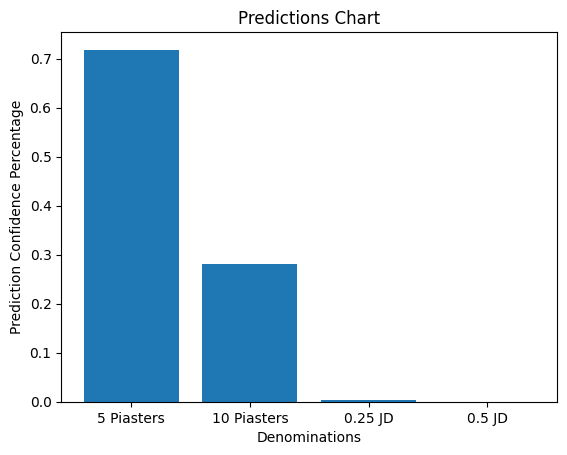

In [353]:
fig, ax = coin_model.plot_predictions(pred)

plt.show()

In [354]:
coins_found = bboxs

In [355]:
len(coins_found)

7

In [356]:
def predict_coin(coin_image):
    model = coin_model.CoinModel()
    pred = model.predict_image(coin_image)
    pred.sort()
    pred = pred[::-1]
    return pred

In [357]:
def predict_all(coin_list, num_of_workers= 8):
    with Pool(num_of_workers) as p:
        return p.map(predict_coin, coin_list)

In [358]:
preds = []
for i, coin in enumerate(coins_found):
    print(f'Predicting : {i}')
    pred = model.predict_image(coin)
    pred.sort()
    pred = pred[::-1]
    preds.append(pred[0][1])

Predicting : 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicting : 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicting : 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicting : 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicting : 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicting : 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predicting : 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [359]:
preds

['5 Piasters',
 '10 Piasters',
 '5 Piasters',
 '0.25 JD',
 '0.25 JD',
 '0.5 JD',
 '10 Piasters']

In [360]:
def get_coin_value(coin_str):
    
    coin_value_map = {
        '5 Piasters' : 0.05,
        '10 Piasters' : 0.10,
        '0.25 JD' : 0.25,
        '0.5 JD' : 0.5,
    }

    return coin_value_map[coin_str]

In [361]:
preds_value = list(map(get_coin_value, preds))

In [362]:
total_ammount = np.array(preds_value).sum()

In [363]:
total_ammount

np.float64(1.3)